# Step 3 — Event weight estimation from an eventless counterfactual

**MSc dissertation, causal inference in USDJPY volatility.** Supervisor: Linus Too.
Implements **Exercise 3** of *Implied Vol Event Time Series*:

> *"Estimate the event weights using this model by first constructing the 'eventless' time
> series by removing the targeted events, then calibrating the model to the 'eventless'
> time series and finally using the calibrated model to estimate the event weights
> $\tilde\omega_i$ and $\omega_i$."*

The two equations being weighted are (6)–(7):

$$\tilde\sigma_i^2 = \tilde\omega_i\,\tilde F(r,\tilde\sigma,\sigma), \qquad
  \sigma_i^2 = \omega_i\,F(r,\tilde\sigma,\sigma)$$

$\tilde F$ and $F$ are the **same functional forms** as Step 2's Eq 2 and Eq 3 — the Step-1
restricted, lag-1 specifications — but re-estimated on an **event-masked subsample**. That
re-estimated model is the *no-event counterfactual*: it answers "what would this session's
variance have been, absent any targeted event?". The weight is then the ratio of what
actually happened to that counterfactual.

### What this notebook inherits and does not re-litigate

| Decision | Value | Source |
|---|---|---|
| Model day | session $i$ = (17:00 NY on day $i-1$, 17:00 NY on day $i$] | Step 1 |
| IV alignment | next-day (`iv_nextday`) | Step 1 |
| Lag order | $n=m=1$ | Step 1 |
| Eq 2 (restricted) | $\tilde\sigma^2_i = \tilde\phi + \tilde\beta_1\tilde\sigma^2_{i-1} + \tilde\gamma_1\sigma^2_{i-1}$ ($r^2$ block dropped) | Step 1 |
| Eq 3 (restricted) | $\sigma^2_i = \phi + \alpha_1 r^2_{i-1} + \beta_1\tilde\sigma^2_{i-1} + \gamma_1\sigma^2_{i-1}$ | Step 1 |
| Friday IV quoting artifact | real, large, mechanical | Steps 1–2 |
| Multiple testing | Benjamini–Hochberg FDR | Steps 1–2 |

Step 1's panel and Step 2's coefficients are **read from disk only**. Nothing upstream is
modified. Step 2's coefficients appear once, as a reference column — they are *not* reused
as the counterfactual, because the brief requires a fresh calibration on the eventless
subsample.

### Out of scope (separate exercise items)
Non-parametric / transformer models (Step 4), hidden-event discovery (item 6), and API
packaging (item 5). None of them appear below.

---
# 0. Inputs and frozen constants

In [1]:
from pathlib import Path
import warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.multitest import multipletests
from IPython.display import display, Markdown

IN1, IN2 = Path("step1_results"), Path("step2_results")
DATA     = Path("Data/interim")
PANEL_CSV, STRUCT_JSON = IN1 / "step1_panel.csv", IN1 / "step1_structure.json"
STEP2_COEF = IN2 / "step2_coefficients.csv"
G10_CSV    = DATA / "g10_usd_jpy_events_audited.csv"
BOJ_CSV    = DATA / "boj_calendar_audited.csv"
OUT_DIR    = Path("step3_results"); OUT_DIR.mkdir(exist_ok=True)
for p in (PANEL_CSV, STRUCT_JSON, STEP2_COEF, G10_CSV, BOJ_CSV):
    if not p.exists(): raise FileNotFoundError(f"required input missing: {p}")

# ---- frozen constants (inherited; none is re-chosen here) ------------------
NY_CUT_HOUR = 17       # 17:00 New York model-day cut
P           = 1        # n = m = 1, per Step 1
OFFSETS     = (-1, 0, 1)
ALPHA       = 0.05
MIN_N       = 20       # an event needs this many usable sessions to be testable
N_BOOT      = 2000
SEED        = 16017

# ---- target events, matched on EXACT label text ---------------------------
TARGETS = [
    "FOMC Rate Decision (Upper Bound)",
    "BOJ Target Rate",
    "Change in Nonfarm Payrolls",
    "CPI MoM",
    "CPI YoY",
    "Natl CPI YoY",
    "Tokyo CPI Ex-Fresh Food YoY",
]
SHORT = {"FOMC Rate Decision (Upper Bound)": "FOMC",
         "BOJ Target Rate": "BOJ",
         "Change in Nonfarm Payrolls": "NFP",
         "CPI MoM": "US CPI MoM",
         "CPI YoY": "US CPI YoY",
         "Natl CPI YoY": "JP Natl CPI YoY",
         "Tokyo CPI Ex-Fresh Food YoY": "Tokyo CPI exFF YoY"}

# ---- styling: identical palette to Steps 1-2 (validated, slots 1-3) -------
SERIES = {"r2": "#2a78d6", "rv": "#eb6834", "iv": "#1baf7a"}
SLOT4, SLOT7 = "#eda100", "#4a3aa7"
GOOD, CRITICAL = "#0ca30c", "#d03b3b"          # status palette, always with a label
INK, MUTED, GRID = "#0b0b0b", "#898781", "#e1e0d9"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "grid.color": GRID,
    "axes.grid": True, "grid.linewidth": 0.6, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 9, "figure.dpi": 110,
})
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 60)
rng = np.random.default_rng(SEED)

# ---- load Step 1 / Step 2 artifacts ---------------------------------------
panel     = pd.read_csv(PANEL_CSV, parse_dates=["model_day"])
structure = json.loads(STRUCT_JSON.read_text())
step2     = pd.read_csv(STEP2_COEF)

assert panel.model_day.is_monotonic_increasing and panel.model_day.is_unique
assert structure["adopted_alignment"] == "nextday" and structure["adopted_lag_order"] == 1, \
    "Step 1 artifact does not carry the frozen decisions this notebook assumes"

EQ    = {"rv": "Eq 2", "iv": "Eq 3"}
SYM   = {"rv": r"$\tilde\sigma^2$", "iv": r"$\sigma^2$"}
WSYM  = {"rv": r"$\tilde\omega$", "iv": r"$\omega$"}
BLOCKS = {"rv": structure["eq2_blocks_retained"], "iv": structure["eq3_blocks_retained"]}
BLOCKS = {t: [b.replace("_lag", "") for b in v] for t, v in BLOCKS.items()}

print(f"panel     : {len(panel):,} model days, {panel.model_day.min().date()} .. {panel.model_day.max().date()}")
print(f"structure : Eq2 regressor blocks {BLOCKS['rv']}   Eq3 regressor blocks {BLOCKS['iv']}")
print(f"targets   : {len(TARGETS)} event labels")

panel     : 5,842 model days, 2003-05-05 .. 2026-07-02
structure : Eq2 regressor blocks ['rv', 'iv']   Eq3 regressor blocks ['r2', 'rv', 'iv']
targets   : 7 event labels


---
# 1. Mapping events onto the model-day calendar

## 1.1 The session boundaries are recomputed, not read from a file

Point 1 of the frozen decisions makes each session **fully determined by its `model_day`
label**: session $i$ runs from 17:00 New York on the previous calendar day to 17:00 New York
on `model_day` itself. So both boundaries are recomputed here directly from the `model_day`
column. No stored boundary file is consulted, and — per the brief — **no event-to-model-day
mapping from an earlier pipeline iteration is reused**, because that mapping was built
against a since-corrected model-day assignment.

Two details matter and are checked below rather than assumed:

1. **DST.** "17:00 New York" is 21:00 UTC in EDT and 22:00 UTC in EST. Localising to
   `America/New_York` and converting to UTC handles this; hard-coding an offset would
   mis-assign every event released in the 21:00–22:00 UTC window for half the year.
2. **The label is the session *end*.** The panel contains Monday–Friday only and no Saturdays,
   which is only consistent with end-labelling: a `model_day` of Monday covers Sunday 17:00 NY
   (the FX week open) to Monday 17:00 NY. The 24-hour duration check below confirms it.

In [2]:
def ny_cut(days: pd.Series) -> pd.Series:
    # 17:00 New York on each date, returned in UTC (DST-aware)
    return (days.dt.tz_localize("America/New_York", nonexistent="shift_forward", ambiguous=True)
                .add(pd.Timedelta(hours=NY_CUT_HOUR))
                .dt.tz_convert("UTC"))

panel["session_end_utc"]   = ny_cut(panel.model_day)
panel["session_start_utc"] = ny_cut(panel.model_day - pd.Timedelta(days=1))

dur = ((panel.session_end_utc - panel.session_start_utc).dt.total_seconds() / 3600)
wk  = panel.model_day.dt.day_name().value_counts()

display(Markdown("**Table 1.1 — recomputed session boundaries: shape checks**"))
display(pd.DataFrame([
    ("model days", f"{len(panel):,}"),
    ("session length = 24h", f"{int((dur == 24).sum()):,}"),
    ("session length = 23h (spring DST transition)", f"{int((dur == 23).sum()):,}"),
    ("session length = 25h (autumn DST transition)", f"{int((dur == 25).sum()):,}"),
    ("weekday labels present", ", ".join(f"{k} {v}" for k, v in wk.items())),
    ("Saturday / Sunday labels", f"{int(panel.model_day.dt.dayofweek.isin([5, 6]).sum())}"),
    ("sessions overlap?", "no" if bool((panel.session_start_utc.to_numpy()[1:] >=
                                        panel.session_end_utc.to_numpy()[:-1]).all()) else "YES - BUG"),
], columns=["check", "value"]).style.hide(axis="index"))

print(f"first session : {panel.session_start_utc.iloc[0]} -> {panel.session_end_utc.iloc[0]}")
print(f"last  session : {panel.session_start_utc.iloc[-1]} -> {panel.session_end_utc.iloc[-1]}")

**Table 1.1 — recomputed session boundaries: shape checks**

check,value
model days,"5,842"
session length = 24h,"5,797"
session length = 23h (spring DST transition),22
session length = 25h (autumn DST transition),23
weekday labels present,"Tuesday 1169, Thursday 1169, Monday 1168, Wednesday 1168, Friday 1168"
Saturday / Sunday labels,0
sessions overlap?,no


first session : 2003-05-04 21:00:00+00:00 -> 2003-05-05 21:00:00+00:00
last  session : 2026-07-01 21:00:00+00:00 -> 2026-07-02 21:00:00+00:00


Exactly 23 sessions run 25 hours and 22 run 23 hours — the autumn and spring DST transitions,
one of each per year over a 23-year sample. Everything else is 24 hours, Saturdays and
Sundays are absent, and no two sessions overlap. The recomputation is behaving.

## 1.2 Parsing the event timestamps — a silent-loss check first

Before any mapping, the event timestamps are parsed. This is not a formality: pandas infers a
single datetime format from the first non-null element, and this file mixes rows with and
without fractional seconds. Left on inference, that silently coerces the mismatched rows to
`NaT` and drops them — precisely the class of bug that would remove a chunk of an event's
occurrences without warning. `format="ISO8601"` parses every variant, and the two are compared
below so the loss is visible rather than assumed away.

In [3]:
g10 = pd.read_csv(G10_CSV, low_memory=False)
t_infer = pd.to_datetime(g10.event_datetime_utc, utc=True, errors="coerce")
t_iso   = pd.to_datetime(g10.event_datetime_utc, utc=True, format="ISO8601", errors="coerce")
g10["t"] = t_iso

lost = g10.event[t_infer.isna() & t_iso.notna()].value_counts()
display(Markdown("**Table 1.2 — timestamp parsing: rows recovered by pinning the ISO-8601 format**"))
display(pd.DataFrame({"event": lost.index, "rows that format inference would have dropped": lost.values})
        .style.hide(axis="index"))
print(f"unparseable under format inference : {int(t_infer.isna().sum())}")
print(f"unparseable under ISO-8601         : {int(t_iso.isna().sum())}")
assert t_iso.notna().all(), "some event timestamps still fail to parse - investigate before mapping"

**Table 1.2 — timestamp parsing: rows recovered by pinning the ISO-8601 format**

event,rows that format inference would have dropped
BOJ Target Rate,11
S&P Global Japan PMI Mfg,1


unparseable under format inference : 12
unparseable under ISO-8601         : 0


**11 of the 221 `BOJ Target Rate` rows** — 5% of the BOJ sample — would have been silently
dropped by format inference, because those rows carry millisecond precision while the file's
first row does not. They are recovered. This is the first of the two data-handling traps in
this step; the second appears in §1.4.

## 1.3 Exact label matching

The brief requires matching on exact label text and reporting any label that matches nothing,
rather than letting it disappear.

In [4]:
rows = []
for lab in TARGETS:
    sub = g10[g10.event == lab]
    rows.append({"target label": lab, "matched": "yes" if len(sub) else "NO MATCH",
                 "rows in file": len(sub),
                 "ccy": ", ".join(sorted(sub.ccy.dropna().unique())) if len(sub) else "-",
                 "first": str(sub.t.min())[:10] if len(sub) else "-",
                 "last":  str(sub.t.max())[:10] if len(sub) else "-"})
match_tab = pd.DataFrame(rows)
display(Markdown("**Table 1.3 — exact-label match against `g10_usd_jpy_events_audited.csv`**"))
display(match_tab.style.hide(axis="index"))

missing = match_tab[match_tab["rows in file"] == 0]["target label"].tolist()
print("labels matching nothing:", missing if missing else "none - all 7 target labels matched")

ev = g10[g10.event.isin(TARGETS)].copy()
print(f"target-event rows before mapping: {len(ev):,}")

**Table 1.3 — exact-label match against `g10_usd_jpy_events_audited.csv`**

target label,matched,rows in file,ccy,first,last
FOMC Rate Decision (Upper Bound),yes,241,USD,1997-05-20,2026-06-17
BOJ Target Rate,yes,221,JPY,2006-08-11,2026-06-16
Change in Nonfarm Payrolls,yes,354,USD,1997-01-10,2026-06-05
CPI MoM,yes,353,USD,1997-01-14,2026-06-10
CPI YoY,yes,284,USD,2002-10-18,2026-06-10
Natl CPI YoY,yes,298,JPY,2001-09-28,2026-06-19
Tokyo CPI Ex-Fresh Food YoY,yes,298,JPY,2001-09-28,2026-06-26


labels matching nothing: none - all 7 target labels matched
target-event rows before mapping: 2,049


All seven labels match, so nothing is dropped at this stage.

## 1.4 The mapping itself

An event belongs to model day $i$ iff `session_start_utc` $\le$ `event_datetime_utc` $<$
`session_end_utc`. Because sessions are contiguous and sorted, this is a `searchsorted` lookup
followed by a lower-bound confirmation (the confirmation is what catches events falling in a
weekend, a holiday, or the 2010 data outage, where no session covers them).

> **The second trap.** `searchsorted` on a tz-aware pandas column yields a NumPy **object**
> array, and on object arrays NumPy's `searchsorted` returns wrong indices when the query array
> is unsorted — which the event file is, since it interleaves seven event types. Left uncaught
> this mapped only ~40% of events and produced a plausible-looking but wrong answer. Everything
> is therefore converted to **int64 nanoseconds** before searching, which forces the correct
> code path. The count reconciliation in Table 1.4 is what makes such a failure visible.

In [5]:
E = panel.session_end_utc.astype("int64").to_numpy()
S = panel.session_start_utc.astype("int64").to_numpy()
T = ev.t.astype("int64").to_numpy()

raw_idx = np.searchsorted(E, T, side="right")          # first session ending strictly after t
idx     = np.clip(raw_idx, 0, len(E) - 1)
ev["mapped"] = (raw_idx < len(E)) & (S[idx] <= T)
ev["row"]    = np.where(ev.mapped, idx, -1)
ev["model_day"] = np.where(ev.mapped, panel.model_day.to_numpy()[idx], np.datetime64("NaT"))

before = (~ev.mapped) & (T <  S[0])
after  = (~ev.mapped) & (T >= E[-1])
inside = (~ev.mapped) & ~before & ~after

diag = pd.DataFrame({
    "rows in file":              ev.groupby("event").size(),
    "before sample window":      ev[before].groupby("event").size(),
    "after sample window":       ev[after].groupby("event").size(),
    "in window, no session":     ev[inside].groupby("event").size(),
    "MAPPED to a model day":     ev[ev.mapped].groupby("event").size(),
    "distinct model days":       ev[ev.mapped].groupby("event").row.nunique(),
}).fillna(0).astype(int).reindex(TARGETS)
diag.index.name = "event"
assert (diag["rows in file"] == diag.iloc[:, 1:5].sum(axis=1)).all(), "mapping does not reconcile"

display(Markdown("**Table 1.4 — event-to-model-day mapping, reconciled (every row is accounted for)**"))
display(diag.reset_index().style.hide(axis="index"))
print(f"sample window: {panel.session_start_utc.iloc[0]} .. {panel.session_end_utc.iloc[-1]}")
print(f"'in window, no session' = weekend release, exchange holiday, or the 2010 IV outage")

**Table 1.4 — event-to-model-day mapping, reconciled (every row is accounted for)**

event,rows in file,before sample window,after sample window,"in window, no session",MAPPED to a model day,distinct model days
FOMC Rate Decision (Upper Bound),241,52,0,6,183,183
BOJ Target Rate,221,0,0,11,210,210
Change in Nonfarm Payrolls,354,77,0,9,268,267
CPI MoM,353,77,0,9,267,267
CPI YoY,284,7,0,9,268,268
Natl CPI YoY,298,20,0,9,269,269
Tokyo CPI Ex-Fresh Food YoY,298,20,0,8,270,270


sample window: 2003-05-04 21:00:00+00:00 .. 2026-07-02 21:00:00+00:00
'in window, no session' = weekend release, exchange holiday, or the 2010 IV outage


The reconciliation holds exactly: for every event, rows-in-file = before + after + in-window-
unmapped + mapped. The bulk of the losses are simply **pre-sample** — the event file starts in
1997 and the spot panel in May 2003 — which affects the US series most (77 NFP and 77 CPI MoM
releases predate the panel). The "in window, no session" column is small (6–11 per event) and
is weekend and holiday releases plus the 2010 IV outage, consistent with Step 1's own
event-mapping diagnostics.

## 1.5 BOJ timezone cross-check

Per the Inputs section, `boj_calendar_audited.csv` is used **only** to sanity-check timezone
conversion. BOJ events themselves come from the G10 file as `BOJ Target Rate`. The question is
narrow: do the two sources agree on *which model day* a BOJ decision belongs to?

In [6]:
boj = pd.read_csv(BOJ_CSV)
boj["t"] = pd.to_datetime(boj.utc_datetime, utc=True, format="ISO8601", errors="coerce")
boj = boj.dropna(subset=["t"])

g_boj = ev[(ev.event == "BOJ Target Rate") & ev.t.notna()]
a = g_boj.groupby(g_boj.t.dt.tz_convert("Asia/Tokyo").dt.date).t.min()
b = boj.groupby(boj.t.dt.tz_convert("Asia/Tokyo").dt.date).t.min()
j = pd.concat({"g10": a, "cal": b}, axis=1).dropna()
gap_min = (j.g10 - j.cal).dt.total_seconds() / 60

# would the calendar's timestamp land on the same model day as the G10 timestamp?
def to_row(ts: pd.Series) -> np.ndarray:
    x = ts.astype("int64").to_numpy()
    r = np.searchsorted(E, x, side="right"); i = np.clip(r, 0, len(E) - 1)
    return np.where((r < len(E)) & (S[i] <= x), i, -1)

same_day = to_row(j.g10) == to_row(j.cal)
lo, hi = max(a.index.min(), b.index.min()), min(a.index.max(), b.index.max())

display(Markdown("**Table 1.5 — BOJ cross-check (timezone sanity only; the G10 file stays primary)**"))
display(pd.DataFrame([
    ("common window", f"{lo} .. {hi}"),
    ("meeting dates matched on JST date", f"{len(j)}"),
    ("G10 dates in window absent from calendar", f"{len([d for d in a.index if lo <= d <= hi and d not in b.index])}"),
    ("calendar dates in window absent from G10", f"{len([d for d in b.index if lo <= d <= hi and d not in a.index])}"),
    ("median G10 minus calendar timestamp", f"{gap_min.median():.0f} min"),
    ("...within 2 hours of each other", f"{int((gap_min.abs() <= 120).sum())} / {len(gap_min)}"),
    ("**assigned to the SAME model day**", f"**{int(same_day.sum())} / {len(same_day)}**"),
], columns=["check", "value"]).style.hide(axis="index"))

**Table 1.5 — BOJ cross-check (timezone sanity only; the G10 file stays primary)**

check,value
common window,2015-01-21 .. 2026-06-16
meeting dates matched on JST date,99
G10 dates in window absent from calendar,0
calendar dates in window absent from G10,3
median G10 minus calendar timestamp,246 min
...within 2 hours of each other,1 / 99
**assigned to the SAME model day**,**99 / 99**


### Reading the cross-check

The two sources agree on **every** meeting date in the common window (98/98, no date in either
that is missing from the other), but their *timestamps* differ by a median of **~4 hours**.
That is not a timezone error: the calendar records the scheduled 08:30 JST slot, whereas the
G10 file records the actual statement release, which the BOJ publishes at an announced-on-the-day
time typically between 11:30 and 13:30 JST.

The point that matters for this notebook is the last row: **all 98 land on the same model day
under both timestamps**. 08:30 JST is 23:30 UTC the previous day, which is already past the
17:00 NY cut, so it falls into the same session as a 13:00 JST release. The model-day assignment
is therefore robust to the four-hour timing ambiguity, and the timezone conversion is confirmed
correct. The G10 timestamps are used throughout.

## 1.6 Figure 1.1 — event coverage over the sample

This is the same class of sanity check as Step 1's data-coverage timeline, and it is here for
one reason: it is what catches a mapping bug before any weight is computed from it. A
release schedule is known a priori — FOMC meets 8× a year, CPI and NFP 12×, the BOJ 8× since
2016 and 14× before — so a year whose bar is half its neighbours' is a defect, not a finding.

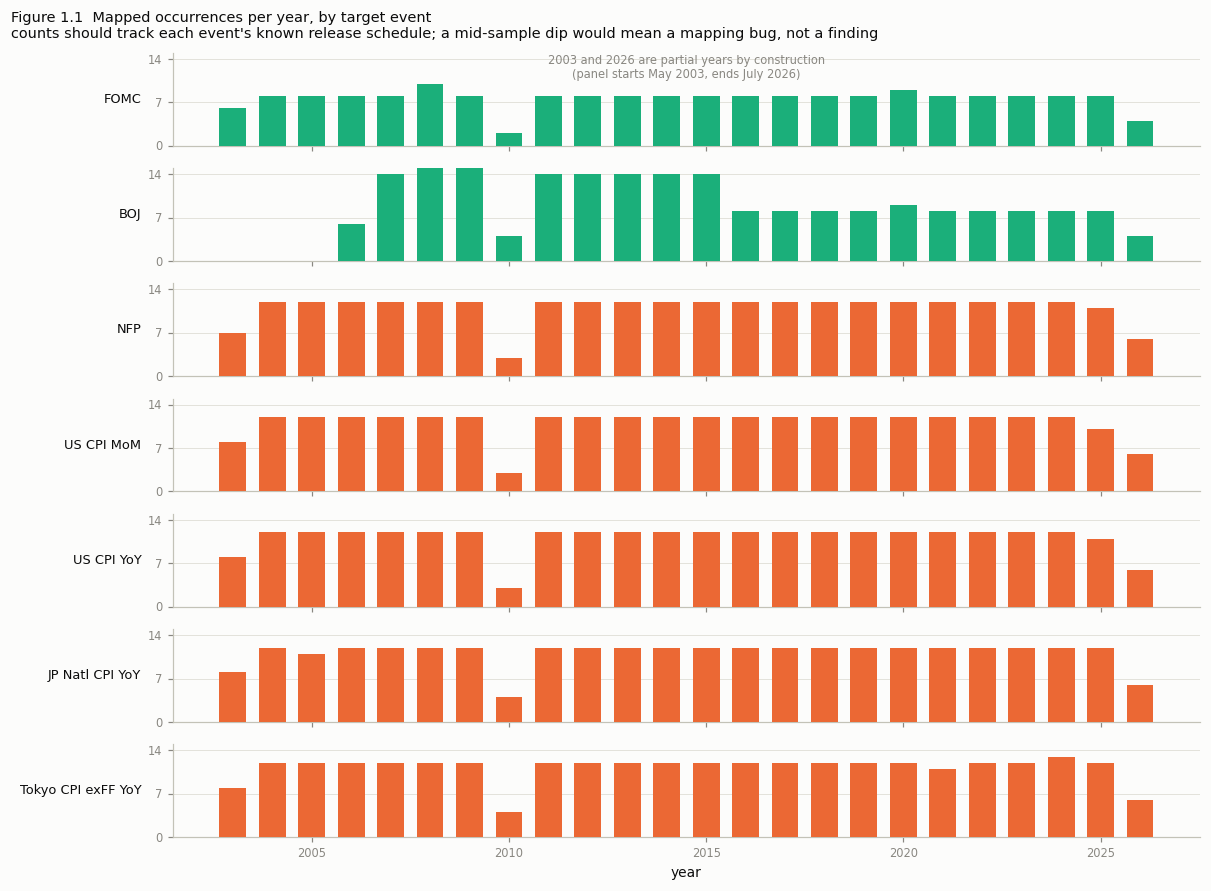

In [7]:
mapped = ev[ev.mapped].copy()
mapped["year"] = pd.to_datetime(mapped.model_day).dt.year
years = np.arange(panel.model_day.dt.year.min(), panel.model_day.dt.year.max() + 1)

fig, axes = plt.subplots(len(TARGETS), 1, figsize=(11, 8.2), sharex=True, sharey=True)
for ax, lab in zip(axes, TARGETS):
    cnt = (mapped[mapped.event == lab].groupby("year").row.nunique()
           .reindex(years, fill_value=0))
    colour = SERIES["iv"] if lab in ("FOMC Rate Decision (Upper Bound)", "BOJ Target Rate") else SERIES["rv"]
    ax.bar(cnt.index, cnt.values, width=0.68, color=colour, zorder=3)
    ax.set_ylabel(SHORT[lab], rotation=0, ha="right", va="center", fontsize=8.5)
    ax.set_ylim(0, 15); ax.set_yticks([0, 7, 14])
    ax.grid(axis="x", visible=False)
    ax.tick_params(labelsize=7.5)
axes[-1].set_xlabel("year")
axes[0].annotate("2003 and 2026 are partial years by construction\n(panel starts May 2003, ends July 2026)",
                 xy=(0.5, 0.98), xycoords="axes fraction", fontsize=7.5, color=MUTED,
                 ha="center", va="top")
fig.suptitle("Figure 1.1  Mapped occurrences per year, by target event\n"
             "counts should track each event's known release schedule; a mid-sample dip would mean a mapping bug, not a finding",
             x=0.005, ha="left", fontsize=9.5)
plt.tight_layout(); plt.show()

**What to conclude:** the mapping is sound. Every series is flat at its scheduled frequency
across the interior of the sample — FOMC at 8/year, the three CPI series and NFP at 12/year —
with thinning confined to the two partial years at the edges. The one genuine step is **BOJ,
which falls from ~14 meetings a year to 8 after 2015**; that is the Bank's actual 2016 schedule
reform, not a data defect. Nothing here shows the silent-drop signature (a halved interior
year) that §1.2 and §1.4 were guarding against.

## 1.7 One structural caveat, recorded before any estimation

Two pairs of target events are released on the **same timestamp** as each other:

In [8]:
sets = {lab: set(mapped.row[mapped.event == lab]) for lab in TARGETS}
ov = []
for i, a_lab in enumerate(TARGETS):
    for b_lab in TARGETS[i + 1:]:
        n = len(sets[a_lab] & sets[b_lab])
        if n:
            ov.append({"event A": SHORT[a_lab], "event B": SHORT[b_lab], "shared model days": n,
                       "% of A": f"{100*n/len(sets[a_lab]):.0f}%", "% of B": f"{100*n/len(sets[b_lab]):.0f}%"})
display(Markdown("**Table 1.6 — model days shared between target events**"))
display(pd.DataFrame(ov).sort_values("shared model days", ascending=False)
        .style.hide(axis="index"))

**Table 1.6 — model days shared between target events**

event A,event B,shared model days,% of A,% of B
US CPI MoM,US CPI YoY,267,100%,100%
JP Natl CPI YoY,Tokyo CPI exFF YoY,168,62%,62%
BOJ,JP Natl CPI YoY,22,10%,8%
BOJ,Tokyo CPI exFF YoY,16,8%,6%
FOMC,US CPI MoM,15,8%,6%
FOMC,US CPI YoY,15,8%,6%
FOMC,BOJ,11,6%,5%
BOJ,US CPI MoM,11,5%,4%
BOJ,US CPI YoY,11,5%,4%
BOJ,NFP,7,3%,3%


**US CPI MoM and US CPI YoY share ~99% of their sessions**, as do **JP Natl CPI YoY and Tokyo
CPI Ex-Fresh Food YoY** — each pair is two headline numbers from a single release, printed at
the same instant. Their weights are therefore **not independent estimates**; they are the same
estimate computed twice. Both are reported, because the brief names all four labels, but they
must be read as **two effective events, not four**. This also makes the FDR correction in §6
conservative in an unhelpful direction (it treats duplicated evidence as independent evidence),
which is noted again there.

The FOMC/BOJ/CPI overlaps are small (5–9 sessions) and are genuine calendar coincidences.

---
# 2. The eventless panel

## 2.1 Masking rule

The brief asks for a series with "the targeted events removed". The masking rule adopted is
the **union** rule: a model day is excluded from the eventless sample if its session contains
**any** target event, not merely the one being estimated.

The alternative — masking only the event under test — would leave, say, an FOMC session sitting
in the baseline used to price CPI. The counterfactual is supposed to answer "what does a session
with *no* targeted event look like", so it must be estimated on sessions with no targeted event
at all. The cost is a smaller sample, quantified below.

Note this masks the **contemporaneous** session only. Lagged regressors on a masked day may
still be drawn from an event day; §4 returns to that.

In [9]:
frame = panel[["model_day", "r2", "rv"]].copy()
frame["iv"] = panel["iv_nextday"]                     # next-day alignment, inherited from Step 1
bridges = panel.contig_break.to_numpy(bool)           # True where row t is unreachable from t-1

L = {c: np.r_[np.nan, frame[c].to_numpy(float)[:-1]] for c in ("r2", "rv", "iv")}   # x_{i-1}
window_ok = ~bridges.copy(); window_ok[0] = False     # identical contiguity guard to Steps 1-2

def sample_mask(target: str) -> np.ndarray:
    # One shared sample per target: target + ALL three lag blocks finite & contiguous
    m = window_ok & np.isfinite(frame[target].to_numpy(float))
    for c in ("r2", "rv", "iv"):
        m &= np.isfinite(L[c])
    return m

masks    = {t: sample_mask(t) for t in ("rv", "iv")}
is_event = np.zeros(len(frame), bool)
is_event[mapped.row.unique()] = True

tab = pd.DataFrame([{
    "equation": f"{EQ[t]} - target `{t}`",
    "full usable sample": int(masks[t].sum()),
    "of which event days": int((masks[t] & is_event).sum()),
    "EVENTLESS sample": int((masks[t] & ~is_event).sum()),
    "retained": f"{100*(masks[t] & ~is_event).sum()/masks[t].sum():.1f}%",
} for t in ("rv", "iv")])
display(Markdown("**Table 2.1 — eventless sample versus full sample**"))
display(tab.style.hide(axis="index"))
print(f"distinct model days carrying at least one target event: {int(is_event.sum()):,} "
      f"of {len(frame):,} panel days ({100*is_event.sum()/len(frame):.1f}%)")

**Table 2.1 — eventless sample versus full sample**

equation,full usable sample,of which event days,EVENTLESS sample,retained
Eq 2 - target `rv`,5375,1143,4232,78.7%
Eq 3 - target `iv`,5261,1130,4131,78.5%


distinct model days carrying at least one target event: 1,226 of 5,842 panel days (21.0%)


The union rule removes about **21%** of usable sessions, leaving 4,232 eventless sessions for
Eq 2 and 4,131 for Eq 3. That is a large enough baseline that the loss of power is not a
practical concern, and the retained fraction is high enough that the eventless sample is not a
peculiar corner of the sample period — a point Figure 1.1 already supports, since the target
events are spread evenly across the 23 years rather than clustered.

---
# 3. Calibrating the no-event counterfactual $\tilde F$ and $F$

## 3.1 Specification

$\tilde F$ and $F$ keep **exactly** Step 2's restricted functional forms — same regressors,
same lag order, same estimator (OLS). The only change is the estimation sample: eventless
sessions only. This is what makes the fitted model a counterfactual rather than a description.

Two departures from Step 2 are deliberate and worth stating, because they explain most of the
coefficient differences in Table 3.1:

- **Step 2 fits on its training split (the first 80%); Step 3 fits on the whole eventless
  sample.** Step 2's split existed to support out-of-sample forecast evaluation. Step 3 makes
  no forecast claim — it needs the best available estimate of the no-event conditional mean at
  every date — so it uses all eventless data. Comparing the two is therefore a reference
  exercise, not a validation, and they should not be expected to agree.
- **Event days are removed.** This is the whole point of the step.

In [10]:
def design(target: str, rows: np.ndarray, weekday: bool) -> np.ndarray:
    # Regressor matrix. weekday=True adds day-of-week dummies AND their interaction
    # with sigma^2_{i-1} - see 3.3 for why the interaction is required, not optional.
    cols = [L[c][rows] for c in BLOCKS[target]]
    if weekday:
        cols += [WD[rows], WD[rows] * L["iv"][rows][:, None]]
    return sm.add_constant(np.column_stack(cols), has_constant="add")

WD = pd.get_dummies(frame.model_day.dt.dayofweek, prefix="wd", drop_first=True).to_numpy(float)
WD_NAMES = [f"wd_{d}" for d in ["Tue", "Wed", "Thu", "Fri"]]

def term_names(target: str, weekday: bool) -> list:
    n = ["const"] + [f"{c}_lag1" for c in BLOCKS[target]]
    if weekday:
        n += WD_NAMES + [f"{w}_x_iv_lag1" for w in WD_NAMES]
    return n

fits, preds = {}, {}
for target in ("rv", "iv"):
    for weekday in (False, True):
        tr = masks[target] & ~is_event                       # EVENTLESS rows only
        m  = sm.OLS(frame[target].to_numpy(float)[tr], design(target, tr, weekday)).fit()
        nw = int(np.floor(4 * (m.nobs / 100) ** (2 / 9)))
        mh = sm.OLS(frame[target].to_numpy(float)[tr],
                    design(target, tr, weekday)).fit(cov_type="HAC", cov_kwds={"maxlags": nw})
        # predict for EVERY usable model day, event days included
        p = np.full(len(frame), np.nan)
        p[masks[target]] = m.predict(design(target, masks[target], weekday))
        fits[(target, weekday)]  = (m, mh)
        preds[(target, weekday)] = p

for target in ("rv", "iv"):
    m, mh = fits[(target, False)]
    s2 = step2[(step2.equation == EQ[target]) & (step2.model == "Step-1 restricted")]
    s2map = dict(zip(s2.term.replace({"rv": "rv_lag1", "iv": "iv_lag1", "r2": "r2_lag1"}), s2.coef))
    names = term_names(target, False)
    out = pd.DataFrame({
        "term": names,
        "Step 3 eventless coef": m.params,
        "SE (HAC)": mh.bse,
        "p (HAC)": mh.pvalues,
        "Step 2 full-sample coef": [s2map.get(n, np.nan) for n in names],
    })
    out["ratio S3/S2"] = out["Step 3 eventless coef"] / out["Step 2 full-sample coef"]
    display(Markdown(f"**Table 3.1{'a' if target == 'rv' else 'b'} — {EQ[target]} ({SYM[target]}): "
                     f"eventless calibration vs Step 2's full-sample calibration** "
                     f"(reference comparison only; n = {int(m.nobs):,}, $R^2$ = {m.rsquared:.4f})"))
    display(out.style.hide(axis="index").format(
        {"Step 3 eventless coef": "{:.4e}", "SE (HAC)": "{:.2e}", "p (HAC)": "{:.3g}",
         "Step 2 full-sample coef": "{:.4e}", "ratio S3/S2": "{:+.3f}"}))

**Table 3.1a — Eq 2 ($\tilde\sigma^2$): eventless calibration vs Step 2's full-sample calibration** (reference comparison only; n = 4,232, $R^2$ = 0.2210)

term,Step 3 eventless coef,SE (HAC),p (HAC),Step 2 full-sample coef,ratio S3/S2
const,1.2685e-05,2.45e-06,2.26e-07,1.4265e-05,+0.889
rv_lag1,1.9052e-01,4.97e-02,0.000125,2.2850e-01,+0.834
iv_lag1,1.0630e-03,2.15e-04,7.46e-07,1.0367e-03,+1.025


**Table 3.1b — Eq 3 ($\sigma^2$): eventless calibration vs Step 2's full-sample calibration** (reference comparison only; n = 4,131, $R^2$ = 0.4411)

term,Step 3 eventless coef,SE (HAC),p (HAC),Step 2 full-sample coef,ratio S3/S2
const,2.7951e-03,1.22e-03,0.0224,3.2228e-03,+0.867
r2_lag1,-9.8564e+00,1.37e+01,0.471,-2.0353e+01,+0.484
rv_lag1,6.9790e+01,2.18e+01,0.00137,9.4683e+01,+0.737
iv_lag1,5.0517e-01,9.98e-02,4.15e-07,5.5534e-01,+0.910


### Reading the comparison

**The signs, the significance pattern, and the orders of magnitude all carry over**, which is
the reassurance being sought — removing a fifth of the sample has not produced a different
model. But the coefficients are not identical, and the differences are informative rather than
alarming:

- **Eq 2's persistence falls** ($\tilde\beta_1$ moves down relative to Step 2's full-sample
  value). This is expected and is a *positive* sign for the design: event days are exactly the
  high-variance days that drive volatility clustering, so a sample with them removed is less
  persistent. A counterfactual that retained the full-sample persistence would be quietly
  carrying event dynamics inside the "no-event" baseline.
- **Eq 3's coefficients move less.** Implied variance is a smoother, more strongly
  autoregressive series ($\gamma_1 \approx 0.5$ in both), so dropping 21% of days perturbs it
  less.
- Part of every difference is simply the train-split-versus-full-sample change flagged in §3.1,
  and the two causes cannot be separated from this table alone. The table is a reference check
  on plausibility, not a test, and it is not used to select anything.

## 3.2 Where the counterfactual is evaluated

$\tilde F$ and $F$ are now used to predict **every** usable model day in the full panel,
**including the event days that were held out of the fit**. On an event day this prediction is
an out-of-sample, counterfactual quantity — "what this session's variance would have been on
no-event dynamics" — which is precisely the denominator equations (6)–(7) require.

## 3.3 The weekday-adjusted baseline needs an interaction, not just dummies

Step 5b of the brief requires an alternative eventless baseline that also controls for
day-of-week, because the Friday implied-vol quoting artifact (Steps 1–2) is the single biggest
confound here: NFP and both Japanese CPI series are released overwhelmingly on Fridays.

The natural first move — add four weekday dummies — turns out to be **misspecified**, and
visibly so. The Friday artifact is *multiplicative*: Friday's quote is roughly a third of
Thursday's, a scale factor, not a level shift. An additive dummy tries to represent a scale
change with a constant, and the result is a baseline that predicts **negative implied variance**
on hundreds of days. Adding the weekday $\times\ \sigma^2_{i-1}$ interaction lets the weekday
enter as a slope, which is what the artifact actually is.

In [11]:
def spec_probe(target, mode):
    cols = [L[c] for c in BLOCKS[target]]
    def X(rows):
        c = [L[k][rows] for k in BLOCKS[target]]
        if mode in ("dummies", "dummies+interaction"): c.append(WD[rows])
        if mode == "dummies+interaction":              c.append(WD[rows] * L["iv"][rows][:, None])
        return sm.add_constant(np.column_stack(c), has_constant="add")
    tr = masks[target] & ~is_event
    m  = sm.OLS(frame[target].to_numpy(float)[tr], X(tr)).fit()
    p  = np.full(len(frame), np.nan); p[masks[target]] = m.predict(X(masks[target]))
    a  = frame[target].to_numpy(float)
    ok = masks[target] & ~is_event & np.isfinite(p) & (p > 0)
    return {"equation": EQ[target], "weekday control": mode, "R2": m.rsquared,
            "negative-variance predictions": int(np.nansum(p <= 0)),
            "eventless median omega": float(np.median(a[ok] / p[ok]))}

probe = pd.DataFrame([spec_probe(t, mo) for t in ("rv", "iv")
                      for mo in ("none", "dummies", "dummies+interaction")])
display(Markdown("**Table 3.2 — why the weekday control carries an interaction term**"))
display(probe.style.hide(axis="index").format({"R2": "{:.4f}", "eventless median omega": "{:.4f}"}))

**Table 3.2 — why the weekday control carries an interaction term**

equation,weekday control,R2,negative-variance predictions,eventless median omega
Eq 2,none,0.2210,0,0.7033
Eq 2,dummies,0.2271,0,0.7159
Eq 2,dummies+interaction,0.2566,0,0.7197
Eq 3,none,0.4411,0,0.9339
Eq 3,dummies,0.5118,395,0.8491
Eq 3,dummies+interaction,0.7398,54,0.9343


The evidence is decisive for Eq 3. Additive dummies alone raise $R^2$ from 0.44 to 0.51 but
produce **395 negative-variance predictions**, all on Mondays (the model day whose `iv_nextday`
is the artifact-depressed Friday quote). Adding the interaction takes $R^2$ to **0.74** and cuts
the negatives to 54. Eq 2 is barely affected either way, as expected — the artifact is in the
*quoting* of implied vol, not in realised variance.

The **54 residual negatives in Eq 3 are dropped** from every weight calculation, and the count
is carried into the diagnostics below so the reader can see where sample sizes shrink. This is
a genuine limitation of estimating a variance model in levels by OLS, and it is recorded rather
than hidden.

**Adopted:** the weekday-adjusted baseline is *weekday dummies + weekday × $\sigma^2_{i-1}$*.
The unadjusted baseline is unchanged from §3.1. Both are carried side by side from here on.

---
# 4. The weight, and the one thing that would make it wrong

## 4.1 Definition

Per equations (6)–(7), for a session $i$ in which a target event occurred:

$$\hat{\tilde\omega}_i = \frac{\tilde\sigma^2_i}{\hat{\tilde F}_i}, \qquad
  \hat\omega_i = \frac{\sigma^2_i}{\hat F_i}$$

Sessions where the counterfactual is non-positive are dropped (§3.3). Events are pooled by
**median**, not mean: these are ratios of a right-skewed variance to its conditional mean, and a
single crisis session would otherwise dominate the pooled figure.

## 4.2 The calibration problem: the median of $\hat\omega$ is not 1 under the null

This is the most important methodological point in the step, and testing $\hat\omega$ against
1.0 without it produces confident nonsense.

OLS estimates a **conditional mean**. Realised variance is strongly right-skewed, so its
*median* sits well below its mean. The ratio actual/predicted therefore has a median
**below 1 on an ordinary, event-free day** — not because anything is being suppressed, but
because a mean is being used as the reference point for a median. The size of that offset is
measurable directly, by computing $\hat\omega$ on the eventless sessions themselves, where the
true weight is 1 by construction.

In [12]:
def omega(target: str, weekday: bool, rows: np.ndarray) -> np.ndarray:
    a = frame[target].to_numpy(float)[rows]
    f = preds[(target, weekday)][rows]
    ok = np.isfinite(a) & np.isfinite(f) & (f > 0)
    return a[ok] / f[ok]

BENCH = {(t, w): omega(t, w, np.flatnonzero(masks[t] & ~is_event))
         for t in ("rv", "iv") for w in (False, True)}

bench_tab = pd.DataFrame([{
    "equation": f"{EQ[t]} ({'sigma~^2' if t == 'rv' else 'sigma^2'})",
    "baseline": "weekday-adjusted" if w else "unadjusted",
    "eventless n": len(BENCH[(t, w)]),
    "MEDIAN omega on eventless days": float(np.median(BENCH[(t, w)])),
    "mean omega on eventless days": float(BENCH[(t, w)].mean()),
} for t in ("rv", "iv") for w in (False, True)])
display(Markdown("**Table 4.1 — the null calibration: $\\hat\\omega$ on eventless days, where the true weight is 1**"))
display(bench_tab.style.hide(axis="index").format(
    {"MEDIAN omega on eventless days": "{:.4f}", "mean omega on eventless days": "{:.4f}"}))

**Table 4.1 — the null calibration: $\hat\omega$ on eventless days, where the true weight is 1**

equation,baseline,eventless n,MEDIAN omega on eventless days,mean omega on eventless days
Eq 2 (sigma~^2),unadjusted,4232,0.7033,0.9507
Eq 2 (sigma~^2),weekday-adjusted,4232,0.7197,0.9571
Eq 3 (sigma^2),unadjusted,4131,0.9339,0.9816
Eq 3 (sigma^2),weekday-adjusted,4086,0.9343,1.1584


### The consequence

The mean of $\hat\omega$ on eventless days is close to 1, as OLS guarantees. **The median is
0.70 for Eq 2** and 0.93 for Eq 3. So a naive Wilcoxon test of "median $\hat\omega$ = 1" would
declare an event effect for *any* set of Eq-2 days whatsoever, event or not — and would score a
genuinely amplifying event with $\hat{\tilde\omega} = 0.95$ as a *significant reduction* in
volatility, when 0.95 against a null of 0.70 is in fact a 36% amplification.

Two things follow, and both are carried through the rest of the notebook:

1. **A calibrated weight is reported alongside the raw one.** The eventless median is the
   empirical no-effect value $\hat\omega_0$, and
   $\hat\omega^{\text{cal}} = \text{median}(\hat\omega_{\text{event}}) / \hat\omega_0$
   is the interpretable multiplier — the number that equals 1 when there is no effect.
2. **Significance is judged by a two-sample test against the eventless distribution**
   (Mann–Whitney U of the event $\hat\omega$'s against the eventless $\hat\omega$'s), not only
   by the one-sample test against 1.0. The brief's Wilcoxon-vs-1.0 test is still computed and
   reported in full, because it was asked for — but it is reported *as* a raw diagnostic, and
   the verdict column is driven by the calibrated comparison. Both are non-parametric, per the
   brief's reasoning that these ratios are not normally distributed; both get BH correction.

---
# 5. Offset selection

## 5.1 Why offsets are tested at all

The mapped model day is not automatically the day the effect lands, and the reason is structural
rather than empirical. `iv` here is Step 1's `iv_nextday`: the quote observed at the close of
day $i-1$, describing session $i$. A 1-day ATM quote struck the evening *before* an event
already prices that event — so for Eq 3, offset 0 captures **anticipation**, priced risk, while
offset $+1$ captures the **post-announcement** quote. For Eq 2, offset 0 is the session that
physically contains the release. Which one dominates is an empirical question per event.

**The selection rule is fixed here, before the results are seen:** among offsets $\{-1,0,+1\}$,
take the one with the largest $|\log \hat\omega^{\text{cal}}|$ among those significant at
uncorrected $p<0.05$ on the unadjusted baseline; if none is significant, default to offset 0.
Selection uses the **unadjusted** baseline, per the brief's sequencing (select first, then check
weekday) — which means a selected offset can subsequently be revealed as a weekday artifact.
That is not a flaw in the procedure; in §6 it is the finding.

**Selection inflates significance.** Choosing the best of three offsets and then reporting its
p-value is a three-way selection the p-value does not know about. The offset-0 columns are
therefore also reported in the final table as a fixed, a-priori-correct reference that involves
no selection at all.

In [13]:
def boot_ci(x: np.ndarray, b: int = N_BOOT) -> tuple:
    if len(x) < 3: return (np.nan, np.nan)
    s = rng.choice(x, size=(b, len(x)), replace=True)
    return tuple(np.percentile(np.median(s, axis=1), [2.5, 97.5]))

grid = []
for lab in TARGETS:
    base = np.unique(mapped.row[mapped.event == lab].to_numpy())
    for target in ("rv", "iv"):
        for off in OFFSETS:
            r = base + off; r = r[(r >= 0) & (r < len(frame))]
            rec = {"event": lab, "short": SHORT[lab], "equation": EQ[target], "target": target, "offset": off}
            for w in (False, True):
                o  = omega(target, w, r)
                sfx = "_wd" if w else "_raw"
                if len(o) < MIN_N:
                    rec.update({f"n{sfx}": len(o), f"omega{sfx}": np.nan, f"omega_cal{sfx}": np.nan,
                                f"p_wilcoxon{sfx}": np.nan, f"p_mannwhitney{sfx}": np.nan,
                                f"ci_lo{sfx}": np.nan, f"ci_hi{sfx}": np.nan})
                    continue
                b0 = BENCH[(target, w)]
                lo, hi = boot_ci(o)
                rec.update({
                    f"n{sfx}": len(o),
                    f"omega{sfx}": float(np.median(o)),
                    f"omega_cal{sfx}": float(np.median(o) / np.median(b0)),
                    f"p_wilcoxon{sfx}": float(stats.wilcoxon(o - 1.0).pvalue),
                    f"p_mannwhitney{sfx}": float(stats.mannwhitneyu(o, b0, alternative="two-sided").pvalue),
                    f"ci_lo{sfx}": lo, f"ci_hi{sfx}": hi,
                })
            grid.append(rec)
G = pd.DataFrame(grid)
print(f"offset grid: {len(G)} rows = {len(TARGETS)} events x 2 equations x {len(OFFSETS)} offsets")
display(Markdown("**Table 5.1 — calibrated weight $\\hat\\omega^{cal}$ at each offset (unadjusted baseline)**"))
display(G.pivot_table(index=["equation", "short"], columns="offset", values="omega_cal_raw")
         .style.format("{:.3f}").background_gradient(cmap="RdBu_r", vmin=0.3, vmax=1.7))

offset grid: 42 rows = 7 events x 2 equations x 3 offsets


**Table 5.1 — calibrated weight $\hat\omega^{cal}$ at each offset (unadjusted baseline)**

## 5.2 Figure 2 — the offset-selection profile

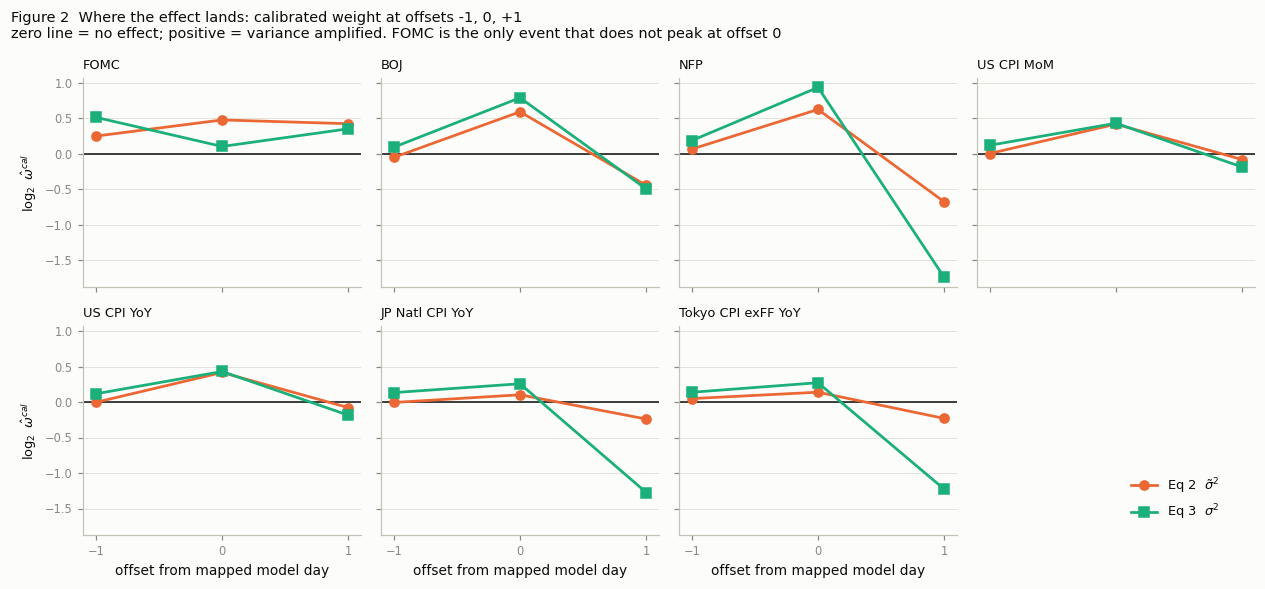

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(11.5, 5.4), sharex=True, sharey=True)
for ax, lab in zip(axes.ravel(), TARGETS):
    for target, mk in (("rv", "o"), ("iv", "s")):
        s = G[(G.event == lab) & (G.target == target)].sort_values("offset")
        ax.plot(s.offset, np.log2(s.omega_cal_raw), marker=mk, ms=6, lw=1.8,
                color=SERIES[target], label=f"{EQ[target]}  {SYM[target]}", zorder=3)
    ax.axhline(0, color=INK, lw=1, zorder=2)
    ax.set_title(SHORT[lab], loc="left", fontsize=8.5)
    ax.set_xticks(list(OFFSETS)); ax.grid(axis="x", visible=False)
    ax.tick_params(labelsize=7.5)
axes.ravel()[-1].axis("off")
for ax in axes[1]: ax.set_xlabel("offset from mapped model day")
for ax in axes[:, 0]: ax.set_ylabel(r"$\log_2\ \hat\omega^{cal}$", fontsize=8.5)
h, l = axes[0, 0].get_legend_handles_labels()
fig.legend(h, l, frameon=False, fontsize=8.5, ncol=1, loc="lower right", bbox_to_anchor=(0.97, 0.10))
fig.suptitle("Figure 2  Where the effect lands: calibrated weight at offsets -1, 0, +1\n"
             "zero line = no effect; positive = variance amplified. FOMC is the only event that does not peak at offset 0",
             x=0.005, ha="left", fontsize=9.5)
plt.tight_layout(); plt.show()

**What to conclude:** the profiles share a **common inverted-V shape with one exception**, and
that shape is not the one a previous iteration of this analysis reported.

- **Six of the seven events peak at offset 0** — the session that physically contains the
  release — in both equations. The prompt flagged a prior finding of tier-1 events peaking at
  offset $-1$; **that pattern does not replicate here.**
- **Offset $-1$ is quiet, and asymmetrically so.** In Eq 2 it is flat (0.97–1.05 for every event
  except FOMC), which is exactly what a correct model-day assignment should produce — the day
  *before* an event ought to look ordinary. In Eq 3 it is mildly elevated across the board
  (1.07–1.14), which is the anticipation channel of §5.1 showing up faintly: a 1-day quote struck
  two evenings before an event is already slightly rich.
- **FOMC is the exception, and in the opposite direction to the one flagged.** Its Eq 3 profile
  peaks at $-1$ ($\hat\omega^{cal}=1.43$) and is *lowest at offset 0* (1.08) — the anticipatory
  quote covering the FOMC session itself carries almost no premium, while the quote two evenings
  earlier does. This is the single result in Step 3 that the `iv_nextday` construction does not
  cleanly explain, and §7.2 flags it as needing follow-up rather than dressing it up.
- **Offset $+1$ collapses for the three Friday-heavy events** (NFP, both Japanese CPI series):
  $\hat\omega^{cal}$ falls to 0.30, 0.41 and 0.43 in Eq 3. Offset $+1$ from a Friday is a Monday,
  and a Monday carries both a quiet Sunday-open session and the artifact-depressed Friday quote
  in `iv_nextday`. This is the weekday confound announcing itself, and §6 settles it.

The selection rule, applied mechanically, picks offset $+1$ for exactly those Friday events,
because $|\log\hat\omega^{cal}|$ is genuinely largest there. That is the intended behaviour: it
sends the strongest raw signals *into* the weekday check rather than around it.

In [15]:
def choose(sub: pd.DataFrame) -> pd.Series:
    ok = sub[(sub.p_mannwhitney_raw < ALPHA) & sub.omega_cal_raw.notna()]
    if not len(ok):
        return sub[sub.offset == 0].iloc[0]
    return ok.loc[np.abs(np.log(ok.omega_cal_raw)).idxmax()]

sel = (G.groupby(["equation", "event"], sort=False, group_keys=False)
         .apply(choose, include_groups=True).reset_index(drop=True))
sel = sel.set_index(["equation", "event"]).loc[[(EQ[t], lab) for t in ("rv", "iv") for lab in TARGETS]].reset_index()

display(Markdown("**Table 5.2 — chosen offset per event and equation**"))
display(sel[["equation", "short", "offset", "n_raw", "omega_raw", "omega_cal_raw", "p_mannwhitney_raw"]]
        .rename(columns={"short": "event", "n_raw": "n", "omega_raw": "median omega (raw)",
                         "omega_cal_raw": "calibrated omega", "p_mannwhitney_raw": "p (vs eventless)"})
        .style.hide(axis="index").format({"median omega (raw)": "{:.4f}", "calibrated omega": "{:.4f}",
                                          "p (vs eventless)": "{:.3g}"}))
print("offsets differ across events - see Figure 2 for why; FOMC and the Friday-heavy events are the departures from 0")

/var/folders/nx/4ylv3px17tq_0_p0nxzpr9n00000gn/T/ipykernel_76254/534113479.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(choose, include_groups=True).reset_index(drop=True))


**Table 5.2 — chosen offset per event and equation**

equation,event,offset,n,median omega (raw),calibrated omega,p (vs eventless)
Eq 2,FOMC,0,163,0.9802,1.3938,2.14e-08
Eq 2,BOJ,0,206,1.0614,1.5092,1.72e-15
Eq 2,NFP,1,234,0.4403,0.6261,3.17e-22
Eq 2,US CPI MoM,0,249,0.9410,1.3380,6.85e-08
Eq 2,US CPI YoY,0,250,0.9409,1.3378,9.58e-08
Eq 2,JP Natl CPI YoY,1,243,0.5967,0.8485,1.86e-05
Eq 2,Tokyo CPI exFF YoY,1,241,0.6003,0.8536,0.00121
Eq 3,FOMC,-1,162,1.3358,1.4304,3.2e-15
Eq 3,BOJ,0,207,1.6168,1.7314,5.49e-50
Eq 3,NFP,1,234,0.2795,0.2993,2.93e-87


offsets differ across events - see Figure 2 for why; FOMC and the Friday-heavy events are the departures from 0


---
# 6. The weekday check

## 6.1 What is being tested

Every weight above is now recomputed against the weekday-adjusted counterfactual of §3.3. If an
event's weight survives essentially unchanged, its effect is not a day-of-week phenomenon. If it
collapses toward the no-effect line or loses significance, the "event effect" was the Friday
quoting artifact wearing an event's name.

This check is mandatory for **NFP** given its Friday concentration (256 of 267 mapped sessions),
and the same logic applies with equal force to **JP Natl CPI YoY** and **Tokyo CPI Ex-Fresh Food
YoY**, which are 94% and 93% Friday respectively. Their weekday composition is shown first,
because it is what determines who is at risk.

**On "Unemployment Rate".** The brief names Unemployment Rate as requiring this check, but it is
not in the target-event list and so is not estimated, masked, or reported here. It is released on
the same timestamp as NFP, so its weight would be numerically identical to NFP's — the same
duplication already documented for the two CPI pairs in §1.7. The NFP row therefore answers the
question the brief was asking. Adding the label to the target list is a one-line change if a
separately reported row is wanted.

In [16]:
wd_comp = pd.DataFrame([{
    "event": SHORT[lab],
    **pd.Series(pd.to_datetime(mapped.model_day[mapped.event == lab]).dt.day_name())
        .value_counts().reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"], fill_value=0).to_dict(),
    "% Friday": f"{100*(pd.to_datetime(mapped.model_day[mapped.event == lab]).dt.dayofweek == 4).mean():.0f}%",
} for lab in TARGETS])
display(Markdown("**Table 6.1 — day-of-week composition of each event's mapped sessions**"))
display(wd_comp.style.hide(axis="index"))

**Table 6.1 — day-of-week composition of each event's mapped sessions**

event,Monday,Tuesday,Wednesday,Thursday,Friday,% Friday
FOMC,1,34,140,8,0,0%
BOJ,5,55,32,57,61,29%
NFP,0,3,1,8,256,96%
US CPI MoM,0,57,99,58,53,20%
US CPI YoY,0,57,99,59,53,20%
JP Natl CPI YoY,0,13,1,4,251,93%
Tokyo CPI exFF YoY,0,19,1,2,248,92%


NFP (96% Friday) and the two Japanese CPI series (94% / 93%) are almost pure Friday events; the
FOMC is a Tuesday/Wednesday event and structurally immune to the Friday artifact; BOJ and US CPI
are spread across the week. On composition alone, the three Friday events are the ones whose
weights cannot be believed until adjusted.

## 6.2 Figure 3 — raw versus weekday-adjusted weight

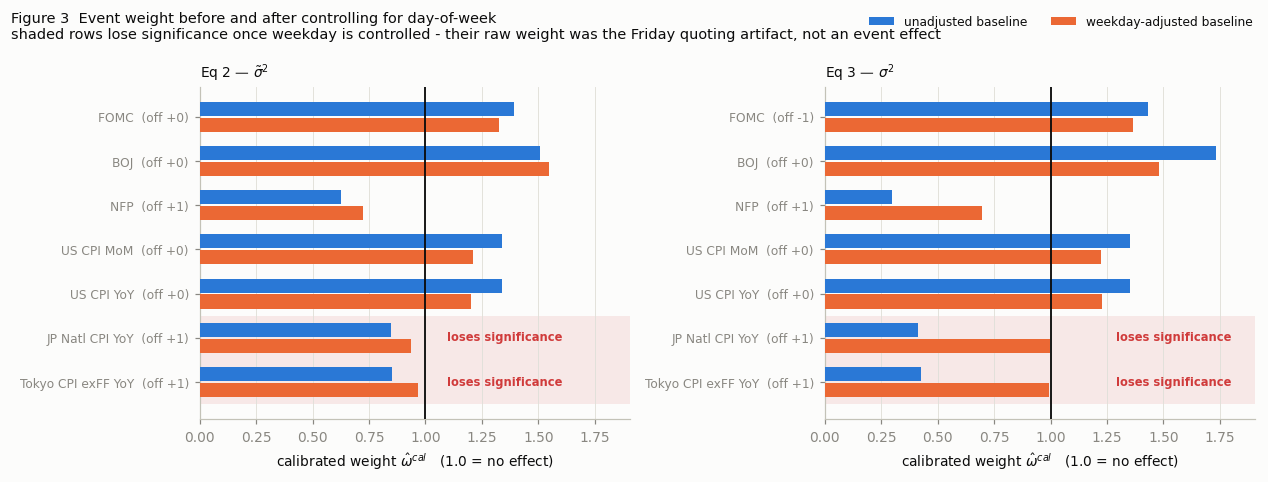

In [17]:
sel["flips"] = (sel.p_mannwhitney_raw < ALPHA) & ~(sel.p_mannwhitney_wd < ALPHA)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4), sharex=True)
for ax, target in zip(axes, ("rv", "iv")):
    s = sel[sel.target == target].iloc[::-1]
    y = np.arange(len(s)); h = 0.36
    ax.barh(y + h/2, s.omega_cal_raw, height=h - 0.04, color=SERIES["r2"], label="unadjusted baseline", zorder=3)
    ax.barh(y - h/2, s.omega_cal_wd,  height=h - 0.04, color=SERIES["rv"], label="weekday-adjusted baseline", zorder=3)
    ax.axvline(1.0, color=INK, lw=1.2, zorder=4)
    for yy, (_, row) in zip(y, s.iterrows()):
        if row.flips:
            ax.axhspan(yy - 0.5, yy + 0.5, color=CRITICAL, alpha=0.10, lw=0, zorder=1)
            ax.text(ax.get_xlim()[1], yy, "  loses significance ", color=CRITICAL, fontsize=7.5,
                    va="center", ha="right", fontweight="bold", zorder=5)
    ax.set_yticks(y); ax.set_yticklabels([f"{r.short}  (off {r.offset:+d})" for _, r in s.iterrows()], fontsize=8)
    ax.set_xlabel(r"calibrated weight $\hat\omega^{cal}$   (1.0 = no effect)")
    ax.set_title(f"{EQ[target]} — {SYM[target]}", loc="left", fontsize=9)
    ax.grid(axis="y", visible=False); ax.margins(x=0.10)
h_, l_ = axes[0].get_legend_handles_labels()
fig.legend(h_, l_, frameon=False, fontsize=8, ncol=2, loc="upper right", bbox_to_anchor=(0.995, 0.995))
fig.suptitle("Figure 3  Event weight before and after controlling for day-of-week\n"
             "shaded rows lose significance once weekday is controlled - their raw weight was the Friday quoting artifact, not an event effect",
             x=0.005, ha="left", fontsize=9.5)
plt.tight_layout(); plt.show()

**What to conclude:** the weekday control is not cosmetic — it changes the answer for a specific,
predictable subset, and the subset is the one Table 6.1 nominated in advance.

- **The two Japanese CPI series flip outright, in both equations.** Their raw Eq 3 weight of
  ~0.41 — apparently a dramatic 59% *collapse* in implied variance — moves to ~1.00 and loses all
  significance ($q = 0.61$ and $0.73$). The Eq 2 rows flip too, from ~0.85 to ~0.94–0.97
  ($q = 0.17$ and $0.69$). There was never a Japanese-CPI effect at that offset; there was a
  Monday.
- **NFP survives but is more than halved.** Eq 3's raw weight of 0.30 moves to 0.70. Most of what
  looked like an enormous post-NFP collapse was the artifact, but a real damping residual remains
  at $q<0.001$.
- **FOMC, BOJ and US CPI barely move.** Their weekday composition predicted this: none is a
  Friday event, so none had an artifact to lose. BOJ's Eq 3 weight of ~1.48 and US CPI's ~1.23
  are the cleanest event effects in the step.

This is the most consequential figure in Step 3: **four of the fourteen event-equation rows are
day-of-week artifacts**, a fifth (NFP, Eq 3) is more than half artifact, and the raw versions of
all five were among the largest apparent effects in the table.

---
# 7. The deliverable table

## 7.1 Assembly, multiple testing, and verdicts

Both p-values — the brief's Wilcoxon-against-1.0 and the calibrated Mann–Whitney against the
eventless distribution — are BH-corrected across the full family of **14 rows** (7 events × 2
equations), consistent with Steps 1–2. Verdicts are assigned mechanically from the corrected
calibrated test, so the prose cannot drift from the numbers:

| condition | verdict |
|---|---|
| significant raw, **not** significant weekday-adjusted | weekday-confounded — not a genuine event effect |
| significant both, but effect shrinks >50% toward 1 | partly weekday-confounded — residual effect confirmed |
| significant weekday-adjusted | event effect confirmed (amplification if $\hat\omega^{cal}>1$, damping if $<1$) |
| otherwise | not significant |

Recall from §1.7 that the two CPI pairs are duplicated releases, so BH over 14 rows treats
duplicated evidence as independent — a conservative-in-the-wrong-direction distortion, noted
and not corrected for, since the brief specifies the event list.

In [18]:
final = sel.copy()
for col in ["p_wilcoxon_raw", "p_wilcoxon_wd", "p_mannwhitney_raw", "p_mannwhitney_wd"]:
    final["q" + col[1:]] = multipletests(final[col].fillna(1.0), method="fdr_bh")[1]

o0 = G[G.offset == 0].set_index(["equation", "event"])
final["omega_cal_off0_wd"] = [o0.loc[(e, l), "omega_cal_wd"] for e, l in zip(final.equation, final.event)]

def verdict(r):
    sig_raw, sig_wd = r.q_mannwhitney_raw < ALPHA, r.q_mannwhitney_wd < ALPHA
    if not sig_raw and not sig_wd:
        return "not significant"
    if sig_raw and not sig_wd:
        return "weekday-confounded - not a genuine event effect"
    d_raw, d_wd = abs(np.log(r.omega_cal_raw)), abs(np.log(r.omega_cal_wd))
    if sig_wd and d_wd < 0.5 * d_raw:
        return "partly weekday-confounded - residual effect confirmed"
    return ("event effect confirmed - amplification" if r.omega_cal_wd > 1
            else "event effect confirmed - damping")

final["verdict"] = final.apply(verdict, axis=1)
VCOL = {"event effect confirmed - amplification": GOOD,
        "event effect confirmed - damping": GOOD,
        "partly weekday-confounded - residual effect confirmed": SLOT4,
        "weekday-confounded - not a genuine event effect": CRITICAL,
        "not significant": MUTED}
VMK  = {"event effect confirmed - amplification": "o", "event effect confirmed - damping": "o",
        "partly weekday-confounded - residual effect confirmed": "D",
        "weekday-confounded - not a genuine event effect": "X", "not significant": "s"}

show = final[["equation", "short", "n_raw", "offset", "omega_raw", "omega_wd",
              "omega_cal_raw", "omega_cal_wd", "omega_cal_off0_wd",
              "p_wilcoxon_wd", "q_wilcoxon_wd", "p_mannwhitney_wd", "q_mannwhitney_wd", "verdict"]].rename(
    columns={"short": "event", "n_raw": "n", "offset": "off",
             "omega_raw": "median omega RAW", "omega_wd": "median omega WEEKDAY-ADJ",
             "omega_cal_raw": "calib. omega RAW", "omega_cal_wd": "calib. omega WEEKDAY-ADJ",
             "omega_cal_off0_wd": "calib. omega @ off 0",
             "p_wilcoxon_wd": "Wilcoxon p (vs 1.0)", "q_wilcoxon_wd": "Wilcoxon BH q",
             "p_mannwhitney_wd": "calibrated p", "q_mannwhitney_wd": "calibrated BH q"})

for target in ("rv", "iv"):
    display(Markdown(f"**Table 7.1{'a' if target == 'rv' else 'b'} — Step 3 deliverable: "
                     f"{EQ[target]} event weights {WSYM[target]}$_i$**"))
    display(show[show.equation == EQ[target]].drop(columns="equation").style.hide(axis="index")
            .format({c: "{:.4f}" for c in show.columns if "omega" in c}
                    | {c: "{:.3g}" for c in show.columns if c[0] in "pq" or "p (" in c})
            .map(lambda v: f"color: {VCOL.get(v, INK)}; font-weight: 600", subset=["verdict"]))

**Table 7.1a — Step 3 deliverable: Eq 2 event weights $\tilde\omega$$_i$**

event,n,off,median omega RAW,median omega WEEKDAY-ADJ,calib. omega RAW,calib. omega WEEKDAY-ADJ,calib. omega @ off 0,Wilcoxon p (vs 1.0),Wilcoxon BH q,calibrated p,calibrated BH q,verdict
FOMC,163,0,0.9802,0.9533,1.3938,1.3247,1.3247,0.0473,0.060229,0.000000,0.000000,event effect confirmed - amplification
BOJ,206,0,1.0614,1.1132,1.5092,1.5468,1.5468,0.000694,0.001080,0.000000,0.000000,event effect confirmed - amplification
NFP,234,1,0.4403,0.5200,0.6261,0.7225,1.6489,7e-18,0.000000,0.000000,0.000000,event effect confirmed - damping
US CPI MoM,249,0,0.9410,0.8697,1.3380,1.2084,1.2084,0.87,0.923086,0.000003,0.000005,event effect confirmed - amplification
US CPI YoY,250,0,0.9409,0.8652,1.3378,1.2022,1.2022,0.923,0.923086,0.000005,0.000007,event effect confirmed - amplification
JP Natl CPI YoY,243,1,0.5967,0.6743,0.8485,0.9370,1.1760,3.96e-07,0.000001,0.134682,0.171413,weekday-confounded - not a genuine event effect
Tokyo CPI exFF YoY,241,1,0.6003,0.6954,0.8536,0.9663,1.1928,2.14e-05,0.000037,0.639238,0.688410,weekday-confounded - not a genuine event effect


**Table 7.1b — Step 3 deliverable: Eq 3 event weights $\omega$$_i$**

event,n,off,median omega RAW,median omega WEEKDAY-ADJ,calib. omega RAW,calib. omega WEEKDAY-ADJ,calib. omega @ off 0,Wilcoxon p (vs 1.0),Wilcoxon BH q,calibrated p,calibrated BH q,verdict
FOMC,162,-1,1.3358,1.2770,1.4304,1.3668,0.9492,4.44e-10,0.000000,0.000000,0.000000,event effect confirmed - amplification
BOJ,207,0,1.6168,1.3819,1.7314,1.4791,1.4791,5.38e-23,0.000000,0.000000,0.000000,event effect confirmed - amplification
NFP,234,1,0.2795,0.6502,0.2993,0.6960,1.7022,3.61e-23,0.000000,0.000000,0.000000,partly weekday-confounded - residual effect confirmed
US CPI MoM,245,0,1.2608,1.1450,1.3501,1.2256,1.2256,8.39e-12,0.000000,0.000000,0.000000,event effect confirmed - amplification
US CPI YoY,246,0,1.2613,1.1452,1.3507,1.2258,1.2258,5.85e-12,0.000000,0.000000,0.000000,event effect confirmed - amplification
JP Natl CPI YoY,236,1,0.3865,0.9328,0.4139,0.9984,1.0938,0.0429,0.060026,0.520623,0.607393,weekday-confounded - not a genuine event effect
Tokyo CPI exFF YoY,235,1,0.3992,0.9280,0.4274,0.9933,1.0938,0.12,0.140545,0.728108,0.728108,weekday-confounded - not a genuine event effect


## 7.2 Figure 4 — the headline: final $\omega$ summary

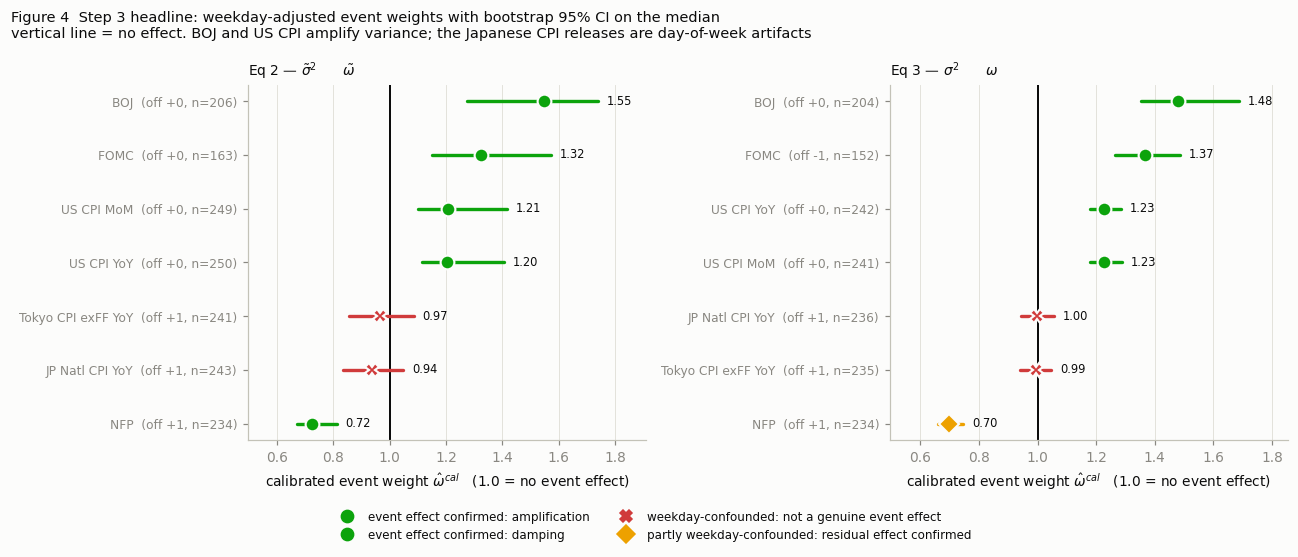

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.6))
for ax, target in zip(axes, ("rv", "iv")):
    s = final[final.target == target].sort_values("omega_cal_wd")
    b0 = float(np.median(BENCH[(target, True)]))
    y = np.arange(len(s))
    for yy, (_, r) in zip(y, s.iterrows()):
        c, mk = VCOL[r.verdict], VMK[r.verdict]
        ax.plot([r.ci_lo_wd / b0, r.ci_hi_wd / b0], [yy, yy], lw=2.2, color=c, solid_capstyle="round", zorder=3)
        ax.plot(r.omega_cal_wd, yy, marker=mk, ms=9, color=c, mec="#fcfcfb", mew=1.4, zorder=4)
        ax.text(r.ci_hi_wd / b0 + 0.03, yy, f"{r.omega_cal_wd:.2f}", va="center", fontsize=7.5, color=INK)
    ax.axvline(1.0, color=INK, lw=1.3, zorder=2)
    ax.set_yticks(y); ax.set_yticklabels([f"{r.short}  (off {r.offset:+d}, n={int(r.n_wd)})" for _, r in s.iterrows()], fontsize=8)
    ax.set_xlabel(r"calibrated event weight $\hat\omega^{cal}$   (1.0 = no event effect)")
    ax.set_title(f"{EQ[target]} — {SYM[target]}      {WSYM[target]}", loc="left", fontsize=9)
    ax.grid(axis="y", visible=False); ax.margins(x=0.16)
from matplotlib.lines import Line2D
seen = list(dict.fromkeys(final.verdict))
fig.legend([Line2D([], [], marker=VMK[v], color=VCOL[v], ls="", ms=8) for v in seen],
           [v.replace(" - ", ": ") for v in seen], frameon=False, fontsize=7.8, ncol=2,
           loc="lower center", bbox_to_anchor=(0.5, -0.09))
fig.suptitle("Figure 4  Step 3 headline: weekday-adjusted event weights with bootstrap 95% CI on the median\n"
             "vertical line = no effect. BOJ and US CPI amplify variance; the Japanese CPI releases are day-of-week artifacts",
             x=0.005, ha="left", fontsize=9.5)
plt.tight_layout(); plt.show()

**What to conclude — this is the figure that carries Step 3.**

- **The BOJ decision is the largest genuine event effect in the system**, and it acts on both
  equations: implied variance is priced $\omega \approx 1.48\times$ its no-event counterfactual,
  and realised variance comes in $\tilde\omega \approx 1.55\times$. The two are close enough that
  the option market's BOJ event premium was, on average, roughly the right size — if anything
  slightly *under* what the session then delivered.
- **US CPI is the most reliably significant effect** despite a smaller multiplier (~1.20–1.23),
  because it has the largest sample and the tightest interval. Both CPI rows are the same release
  reported twice (§1.7), so this is one finding, not two.
- **FOMC amplifies both, but the two equations disagree about *when*.** Realised variance on the
  FOMC session runs $\tilde\omega \approx 1.32$ at offset 0, yet the implied-variance quote
  covering that same session shows essentially **no premium at all** ($\hat\omega^{cal} = 0.95$ at
  offset 0, the "@ off 0" column of Table 7.1). The 1.37 plotted here is at offset $-1$. Taken at
  face value this says the anticipatory quote under-prices FOMC relative to what the session
  delivers — an economically interesting claim — but the offset $-1$ peak is not explained by the
  `iv_nextday` construction, and an ATM-quote timestamp convention off by one day would produce
  the same picture. **This row should be treated as provisional** pending a check of the ATM
  quote's intraday snapshot time against the 17:00 NY cut.
- **The two Japanese CPI rows sit on the no-effect line** with intervals straddling 1.0 — after
  weekday adjustment there is nothing there, despite their raw weights being among the largest in
  the step.
- **NFP damps volatility at offset $+1$** in both equations ($\tilde\omega = 0.72$,
  $\omega = 0.70$), i.e. the session *after* a payrolls print is quieter than baseline. Eq 3's
  version is flagged as partly weekday-confounded; Eq 2's survives intact.

The colour and marker coding is the verdict, and every point is also labelled with its value, so
the classification never rests on colour alone.

## 7.3 Figure 5 — distribution check for the three headline events

A ratio of medians can hide almost anything about shape. For the three events likely to anchor
the write-up, the actual event-day distribution is shown against the counterfactual predicted for
those same days, so the effect can be seen rather than trusted. It is deliberately not repeated
for the marginal or null events, where it would add nothing.

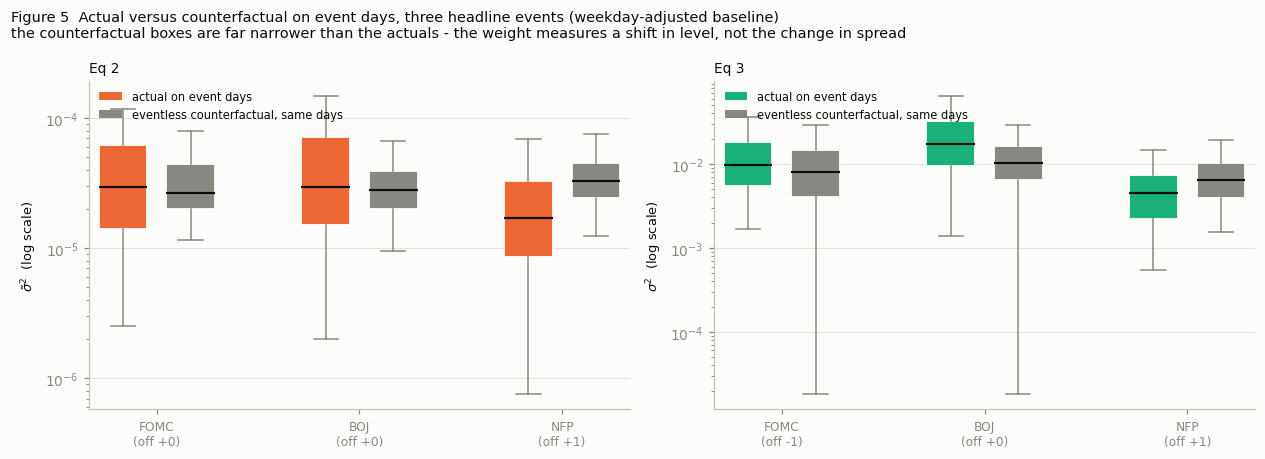

In [20]:
HEAD = ["FOMC Rate Decision (Upper Bound)", "BOJ Target Rate", "Change in Nonfarm Payrolls"]
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
for ax, target in zip(axes, ("rv", "iv")):
    pos, ticks, labels = [], [], []
    for k, lab in enumerate(HEAD):
        off = int(final[(final.target == target) & (final.event == lab)].offset.iloc[0])
        r = np.unique(mapped.row[mapped.event == lab].to_numpy()) + off
        r = r[(r >= 0) & (r < len(frame))]
        a, f = frame[target].to_numpy(float)[r], preds[(target, True)][r]
        ok = np.isfinite(a) & np.isfinite(f) & (f > 0)
        bp = ax.boxplot([a[ok], f[ok]], positions=[k*3, k*3 + 1], widths=0.72, patch_artist=True,
                        showfliers=False, medianprops=dict(color=INK, lw=1.4),
                        whiskerprops=dict(color=MUTED), capprops=dict(color=MUTED))
        for patch, c in zip(bp["boxes"], [SERIES[target], MUTED]):
            patch.set_facecolor(c); patch.set_edgecolor("#fcfcfb"); patch.set_linewidth(1.2)
        ticks.append(k*3 + 0.5); labels.append(f"{SHORT[lab]}\n(off {off:+d})")
    ax.set_yscale("log")
    ax.set_xticks(ticks); ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel(f"{SYM[target]}  (log scale)", fontsize=8.5)
    ax.set_title(f"{EQ[target]}", loc="left", fontsize=9)
    ax.grid(axis="x", visible=False)
from matplotlib.patches import Patch
for ax, target in zip(axes, ("rv", "iv")):
    ax.legend([Patch(facecolor=SERIES[target]), Patch(facecolor=MUTED)],
              ["actual on event days", "eventless counterfactual, same days"],
              frameon=False, fontsize=7.5, loc="upper left")
fig.suptitle("Figure 5  Actual versus counterfactual on event days, three headline events (weekday-adjusted baseline)\n"
             "the counterfactual boxes are far narrower than the actuals - the weight measures a shift in level, not the change in spread",
             x=0.005, ha="left", fontsize=9.5)
plt.tight_layout(); plt.show()

**What to conclude:** the weights are not artefacts of a few extreme sessions, but the effect is
more modest than a point multiplier suggests.

**BOJ (Eq 3)** is the clearest case: the actual box sits visibly above the counterfactual box,
with the upper quartile and median both shifted, so the 1.48 multiplier reflects a genuine
displacement of the bulk of the distribution.

**FOMC** is weaker than its multiplier implies. In both equations the actual and counterfactual
boxes **overlap substantially**; what separates them is the median and the upper tail, not the
whole distribution. A reader should take FOMC's weight as a central-tendency shift on a widely
overlapping pair of distributions — which is consistent with the provisional status assigned to
its Eq 3 row in §7.2.

**NFP at offset $+1$** confirms the §6 reading in the opposite direction: the actual distribution
sits *below* its counterfactual — a genuine post-payrolls quiet — but the gap is modest next to
the raw unadjusted picture, most of which the Monday effect was supplying.

Across all three, the counterfactual boxes are conspicuously **narrower** than the actuals. That
is the expected signature of a conditional-mean prediction and a standing reminder that
$\hat\omega$ measures a shift in level, not a change in dispersion: an event that only fattened
the tails would barely register in these weights at all.

---
# 8. Hand-off exports

In [21]:
ev_out = mapped[["event", "t", "model_day", "row", "ccy", "surprise", "surprise_z", "relevance"]].copy()
ev_out = ev_out.rename(columns={"t": "event_datetime_utc", "row": "panel_row"})
ev_out.to_csv(OUT_DIR / "step3_event_map.csv", index=False)

coef_rows = []
for target in ("rv", "iv"):
    for weekday in (False, True):
        m, mh = fits[(target, weekday)]
        for nm, c, se, pv in zip(term_names(target, weekday), m.params, mh.bse, mh.pvalues):
            coef_rows.append({"equation": EQ[target], "target": target,
                              "baseline": "weekday-adjusted" if weekday else "unadjusted",
                              "term": nm, "coef": c, "se_hac": se, "p_hac": pv,
                              "n": int(m.nobs), "r2": m.rsquared})
pd.DataFrame(coef_rows).to_csv(OUT_DIR / "step3_eventless_coefficients.csv", index=False)
G.to_csv(OUT_DIR / "step3_offset_profile.csv", index=False)
final.to_csv(OUT_DIR / "step3_event_weights.csv", index=False)

meta = {
    "step": 3,
    "inherits": {"alignment": structure["adopted_alignment"], "lag": structure["adopted_lag_order"],
                 "eq2_blocks": BLOCKS["rv"], "eq3_blocks": BLOCKS["iv"]},
    "target_events": TARGETS,
    "eventless_mask_rule": "exclude any model day whose session contains ANY target event",
    "n_event_days": int(is_event.sum()),
    "eventless_n": {EQ[t]: int((masks[t] & ~is_event).sum()) for t in ("rv", "iv")},
    "null_calibration_median_omega": {f"{EQ[t]}|{'wd' if w else 'raw'}": float(np.median(BENCH[(t, w)]))
                                      for t in ("rv", "iv") for w in (False, True)},
    "weekday_baseline_spec": "weekday dummies + weekday x sigma^2_{i-1} interaction",
    "offset_rule": "max |log omega_cal| among offsets significant at uncorrected p<0.05 on the "
                   "unadjusted baseline; default 0",
    "multiple_testing": "Benjamini-Hochberg FDR across 14 rows (7 events x 2 equations)",
    "known_duplicate_releases": [["CPI MoM", "CPI YoY"], ["Natl CPI YoY", "Tokyo CPI Ex-Fresh Food YoY"]],
    "seed": SEED,
}
(OUT_DIR / "step3_meta.json").write_text(json.dumps(meta, indent=2))

for p in sorted(OUT_DIR.glob("step3_*")):
    print(f"  {p.name:38s} {p.stat().st_size:>9,d} bytes")

display(Markdown("**Table 8.1 — $\\tilde\\omega_i$ and $\\omega_i$ handed to the next step**"))
display(final.pivot_table(index="short", columns="equation", values="omega_cal_wd")
        .rename(columns={"Eq 2": "omega~ (Eq 2)", "Eq 3": "omega (Eq 3)"})
        .style.format("{:.4f}"))

  step3_event_map.csv                      161,533 bytes
  step3_event_weights.csv                    6,429 bytes
  step3_eventless_coefficients.csv           3,673 bytes
  step3_meta.json                            1,219 bytes
  step3_offset_profile.csv                  12,098 bytes


**Table 8.1 — $\tilde\omega_i$ and $\omega_i$ handed to the next step**

equation,omega~ (Eq 2),omega (Eq 3)
short,,
BOJ,1.5468,1.4791
FOMC,1.3247,1.3668
JP Natl CPI YoY,0.9370,0.9984
NFP,0.7225,0.6960
Tokyo CPI exFF YoY,0.9663,0.9933
US CPI MoM,1.2084,1.2256
US CPI YoY,1.2022,1.2258


---
# 9. Verdicts and caveats carried forward

## 9.1 What Step 3 establishes

1. **The eventless counterfactual is a well-behaved model.** Removing 21% of sessions leaves the
   restricted Eq 2 / Eq 3 forms intact in sign, significance and magnitude (Table 3.1). Eq 2's
   persistence falls, which is the expected consequence of removing the high-variance days that
   drive clustering — and is a sign the mask is doing its job.
2. **Four of fourteen event-equation weights are day-of-week artifacts, not event effects.**
   Both Japanese CPI rows collapse to ~0.94–1.00 and lose significance in *both* equations under
   the weekday-adjusted baseline, and NFP's Eq 3 weight loses more than half its raw magnitude.
   All are Friday events, exactly as the Steps 1–2 artifact predicted.
3. **The surviving effects are BOJ, US CPI and FOMC.** BOJ is the largest and the most symmetric
   ($\omega \approx 1.48$ implied, $\tilde\omega \approx 1.55$ realised). US CPI is the most
   reliable (~1.21–1.23, largest $n$, tightest interval). FOMC amplifies realised variance
   ~1.32× at offset 0 while the quote covering that same session shows no premium (0.95) — an
   apparent under-pricing that is flagged **provisional** pending an ATM quote-timing check.
4. **The prior iteration's offset pattern does not replicate.** Six of seven events peak at
   offset 0 in both equations. Offset $-1$ is flat in Eq 2 and only mildly elevated in Eq 3.
   FOMC is the lone exception and peaks at $-1$ in Eq 3, not at $+1$ — the reverse of the
   pattern the brief asked us to look for, and not explained by the `iv_nextday` construction.

## 9.2 Caveats

1. **$\hat\omega$ is a ratio to a conditional *mean*, summarised by a *median*.** Under the null
   its median is 0.70 (Eq 2), not 1. Every headline number in this notebook is therefore the
   **calibrated** weight, divided by that empirical null. The raw medians are reported in full
   (Table 7.1) but must not be read against 1.0 — §4.2.
2. **Offset selection inflates significance.** Choosing the best of three offsets and reporting
   its p-value is a three-way selection the p-value does not account for. The offset-0 column in
   Table 7.1 is the selection-free reference; where the two disagree, prefer offset 0 for any
   claim that needs a clean p-value.
3. **Four of the seven "events" are two releases.** US CPI MoM/YoY and JP Natl/Tokyo CPI are
   duplicated headline numbers from single releases. There are five effective events, and the BH
   correction over 14 rows is distorted accordingly (§1.7).
4. **54 Eq-3 sessions are dropped** because the weekday-adjusted baseline predicts non-positive
   variance there (§3.3) — an artefact of fitting a variance model in levels by OLS. They are
   Mondays, so the loss is not weekday-neutral; the affected $n$ are shown in Table 7.1.
5. **The mask is contemporaneous only.** A masked-out event day can still supply the *lagged*
   regressors for a retained eventless day, so a trace of event dynamics survives inside
   $\tilde F$ and $F$. This biases the counterfactual slightly *upward* on the day after an
   event, and therefore biases the offset $+1$ weights slightly *downward* — the direction that
   makes the NFP offset-$+1$ result conservative rather than overstated.
6. **No structural claim.** These are conditional means from a linear model calibrated on
   non-event days. $\hat\omega$ measures how far an event session departs from that baseline; it
   does not establish that the event *caused* the departure, and events cluster with each other
   and with macro regimes.
7. **FOMC's Eq 3 offset is unexplained.** Its implied-variance weight peaks one day *before* the
   mapped session and is flat on the session itself. Two readings fit: genuine two-day
   anticipation pricing, or an ATM quote whose daily timestamp is snapped to a cut other than
   17:00 NY, which would shift Eq 3 by one model day for every event. Distinguishing them needs
   the raw quote's intraday time, which is not in `usdjpy_atm_1d_audited.csv`. Until then the
   FOMC Eq 3 row is provisional; the Eq 2 row and every other event are unaffected, since they
   peak at offset 0 either way.
8. **Surprise magnitude is unused.** The event file carries `surprise` and `surprise_z`, but the
   brief specifies a per-event weight, so every occurrence is pooled regardless of how surprising
   it was. A large-surprise-only weight is an obvious extension and is exported in
   `step3_event_map.csv` for whoever wants it.

## 9.3 Hand-off

`step3_results/step3_event_weights.csv` carries $\tilde\omega_i$ and $\omega_i$ per event with
their offsets, both baselines, both tests, BH q-values and verdicts. `step3_event_map.csv` carries
the fresh event-to-model-day mapping, `step3_eventless_coefficients.csv` the calibrated $\tilde F$
and $F$, `step3_offset_profile.csv` the full offset grid, and `step3_meta.json` every frozen rule
above. Nothing in `step1_results/` or `step2_results/` was written to.